<a href="https://colab.research.google.com/github/grkenney/WinSPIRE-HLC-Python/blob/main/Notebooks/Keys/Day_3.1_Introduction_to_Plotting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Histograms and Bar Charts

In this lesson we're going to learn how to make and customize histograms and bar graphs using a **package** called `seaborn`, which we will give the nickname `sns`.

In [29]:
# import seaborn and nickname it sns
import seaborn as sns

# import matplotlib.pyplot and nickname it plt
import matplotlib.pyplot as plt

# import pandas and nickname it pd
import pandas as pd

# set up inline figures
%matplotlib inline

We will be using the qPCR dataset from the previous lesson in this lesson. Let's load and preview it.

In [9]:
url = 'https://github.com/grkenney/WinSPIRE-HLC-Python/raw/refs/heads/main/data/qPCR_data_cleaned.csv'
df = pd.read_csv(url)
df.head()

,sample_id,treatment_group,well,timepoint,MKI67,MTOR,BAX,IRF1
0,657317,Control,1,0,1.004377,1.379025,0.799135,0.672194
1,657317,Control,2,8,0.894172,1.345400,0.956142,0.756379
2,657317,Control,3,16,0.679445,1.098444,1.209928,0.050000
3,657317,Control,4,24,0.721341,1.063588,1.586136,0.643022
4,407401,Control,5,0,1.091682,0.843497,0.354864,0.489234


## Review

Before we get started with plotting, let's review a few concepts from previous lessons that will be helpful here.
* Subset df to just the `BAX` column
* Subset df to just the rows where `timepoint` > 0
* Make a list that contains the names of three colors

In [87]:
# subset df to just the BAX column
df["BAX"]

0     0.799135
1     0.956142
2     1.209928
3     1.586136
4     0.354864
        ...   
94    1.302101
95    0.660141
96    0.815591
97    0.972522
98    1.341830
Name: BAX, Length: 99, dtype: float64

In [88]:
# subset df to just the rows where timepoint > 0
df.query("timepoint > 0")

,sample_id,treatment_group,well,timepoint,MKI67,MTOR,BAX,IRF1
1,657317,Control,2,8,0.894172,1.345400,0.956142,0.756379
2,657317,Control,3,16,0.679445,1.098444,1.209928,0.050000
3,657317,Control,4,24,0.721341,1.063588,1.586136,0.643022
5,407401,Control,6,8,1.006165,0.744733,0.462132,0.437316
6,407401,Control,7,16,0.937125,10.000000,0.567334,0.486034
...,...,...,...,...,...,...,...,...
93,199598,Treatment,25,16,0.500050,0.572748,1.088869,1.506230
94,199598,Treatment,26,24,0.346927,0.144315,1.302101,1.838012
96,871144,Control,28,8,0.817965,1.407120,0.815591,0.537545
97,871144,Control,29,16,0.708894,1.197898,0.972522,0.499416


In [ ]:
# list of three colors
["red", "yellow", "blue"]

## Histograms

Histograms are used to visualize the *distribution* of a *continuous* variable. 

Let's say we wanted to see how the expression of `BAX` is distributed across all samples and timepoints in our dataset. We can use the `histplot` function to generate our histogram.

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='BAX', ylabel='Count'>

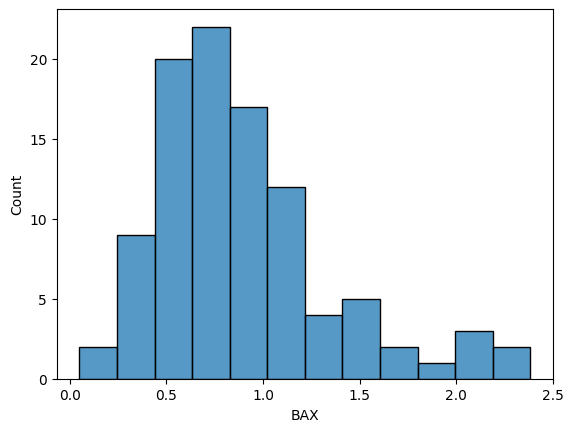

In [52]:
# histogram of BAX
sns.histplot(x = "BAX", data = df)

We can change the width of each bin with the `binwidth` parameter. This changes the granularity of our plot.

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='BAX', ylabel='Count'>

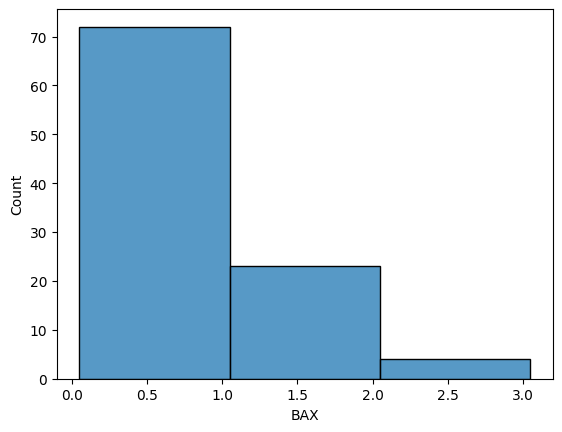

In [53]:
# histogram of BAX with a binwidth of 1
sns.histplot(x = "BAX", data = df, binwidth = 1)

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='BAX', ylabel='Count'>

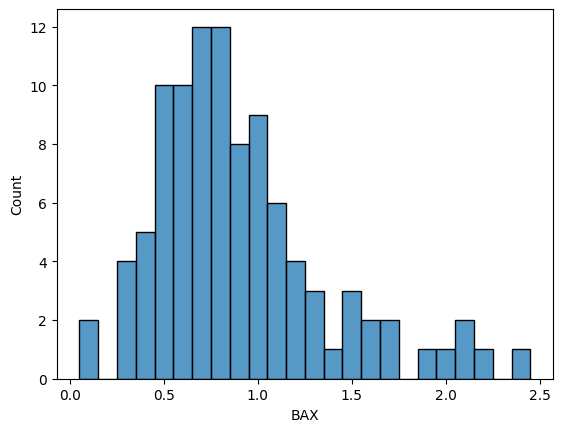

In [55]:
# histogram of BAX with a binwidth of 0.1
sns.histplot(x = "BAX", data = df, binwidth = 0.1)

We can also visualize distributions of multiple columns together. Let's try comparing the distribution of `BAX` and `MKI67` on the same plot.

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


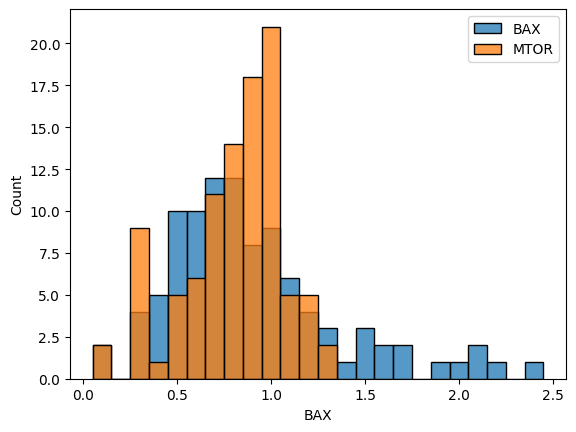

In [57]:
# histogram of BAX
sns.histplot(x = "BAX", data = df, label="BAX", binwidth = 0.1)
# histogram of MKI67
sns.histplot(x = "MKI67", data = df, label="MTOR", binwidth = 0.1)
# plot the legend
plt.legend()

**Exercise:** Now, let's look at the distribution of our other genes (`IRF1` and `MTOR`).
1. Plot the distribution of IRF1
2. Plot the distribution of MTOR
3. Combine the distributions of all genes on the same plot
4. **Challenge:** Let's say we notice some samples with very high MTOR expression and decide that these are due to errors within the lab. How might we exclude these data points from the plot? (Exclude data points where MTOR > 9.)

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='IRF1', ylabel='Count'>

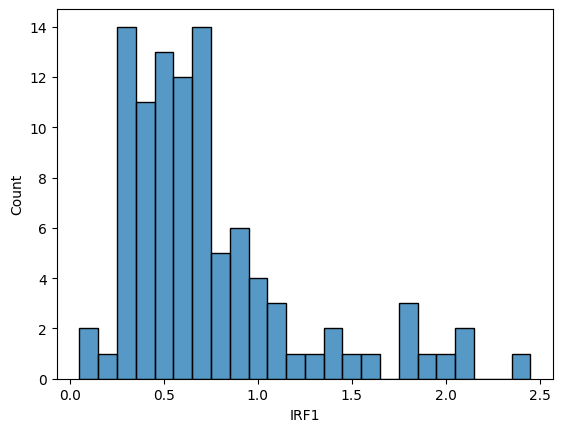

In [60]:
# plot distribution of IRF1
sns.histplot(x = "IRF1", data = df, label="IRF1", binwidth = 0.1)

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='MTOR', ylabel='Count'>

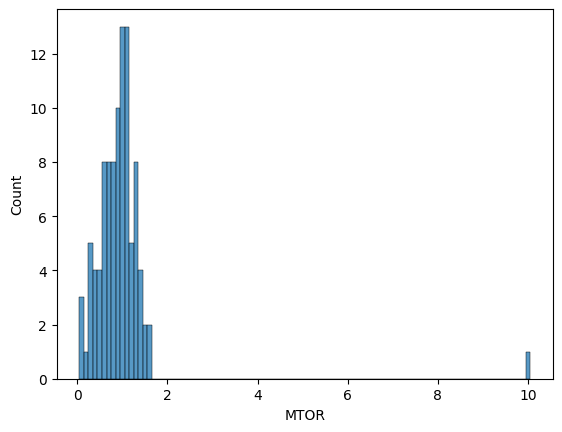

In [59]:
# plot distribution of MTOR
sns.histplot(x = "MTOR", data = df, label="MTOR", binwidth = 0.1)

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

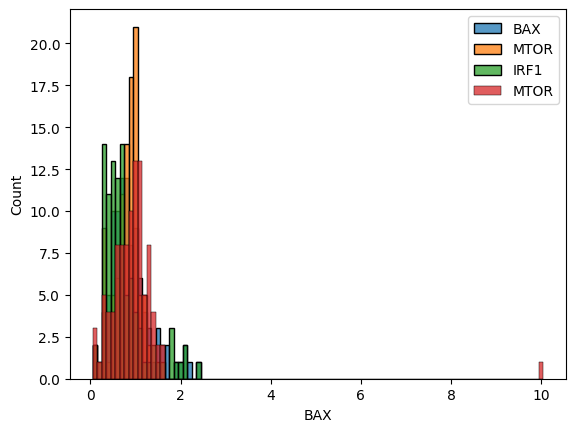

In [61]:
# plot distribution of all genes
sns.histplot(x = "BAX", data = df, label="BAX", binwidth = 0.1)
sns.histplot(x = "MKI67", data = df, label="MTOR", binwidth = 0.1)
sns.histplot(x = "IRF1", data = df, label="IRF1", binwidth = 0.1)
sns.histplot(x = "MTOR", data = df, label="MTOR", binwidth = 0.1)
plt.legend()

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: Futur

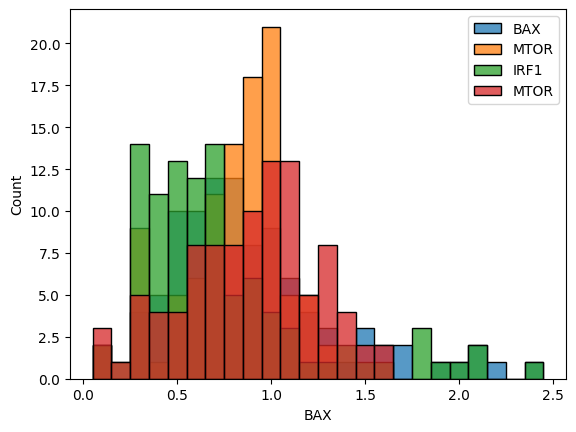

In [62]:
# plot distribution of all genes, excluding data points where MTOR > 9
sns.histplot(x = "BAX", data = df, label="BAX", binwidth = 0.1)
sns.histplot(x = "MKI67", data = df, label="MTOR", binwidth = 0.1)
sns.histplot(x = "IRF1", data = df, label="IRF1", binwidth = 0.1)
sns.histplot(x = "MTOR", data = df.query("MTOR < 9"), label="MTOR", binwidth = 0.1)
plt.legend()

## Bar Charts
Bar charts are used to display how a *categorical* variable relates to a *continuous* variable. In bar charts the *categorical* variable is displayed on the x-axis and the *continuous* variable is displayed on the y-axis.

- Categorical variables are variables with different categories or groups. 
    - Examples: gender, city
- Continuous variables are numeric variables.
    - Examples: time, height, length


<Axes: xlabel='treatment_group', ylabel='BAX'>

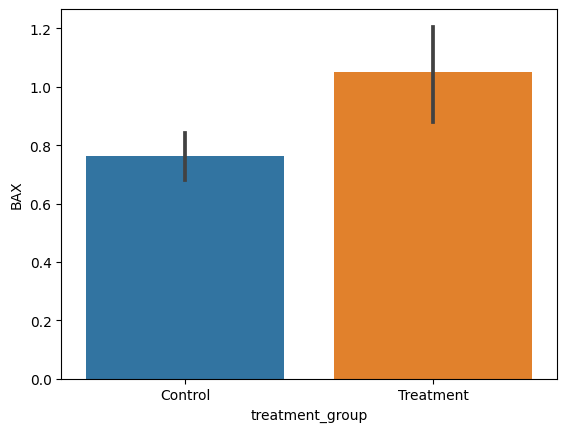

In [65]:
# barplot of treatment_group vs BAX
sns.barplot(x="treatment_group", y = "BAX", data=df)

Notice how seaborn magically computes the mean expression and generates the plot exactly as we want without us even specifying!

What if we wanted to look at the data more granularly and further stratify each treatment group bar by the timepoint variable?

<Axes: xlabel='treatment_group', ylabel='BAX'>

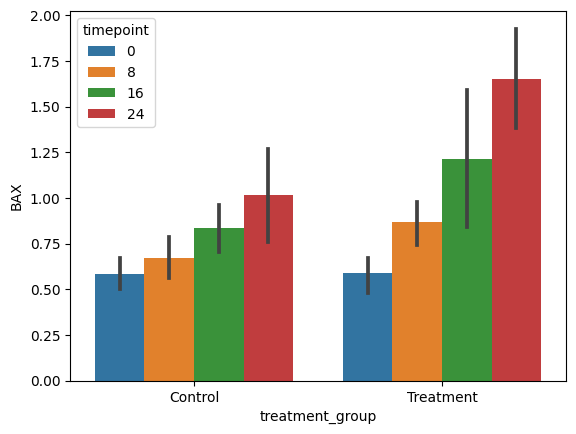

In [71]:
# barplot of treatment_group vs BAX expression stratified by timepoint
sns.barplot(x="treatment_group", y = "BAX", data=df, hue = "timepoint")

**Exercise:** Let's try viewing this same information in a different way.
1. Make a barplot of `timepoint` versus `BAX` expression and stratify by `treatment_group`
2. What aspects of the data are easier to visualize with this new plot?
3. Use a barplot to determine how `IRF1` expression changes over time
4. Now stratify `IRF1` expression across time by `treatment_group`. Does `IRF1` expression respond differently to each treatment?

<Axes: xlabel='timepoint', ylabel='BAX'>

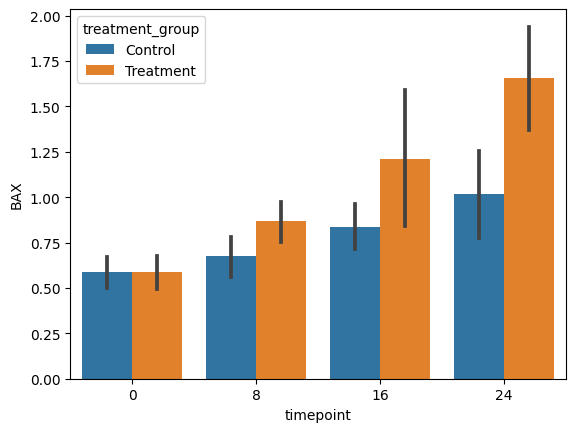

In [72]:
# barplot of timepoint vs BAX stratified by treatment_group
sns.barplot(x="timepoint", y = "BAX", data=df, hue = "treatment_group")

<Axes: xlabel='timepoint', ylabel='IRF1'>

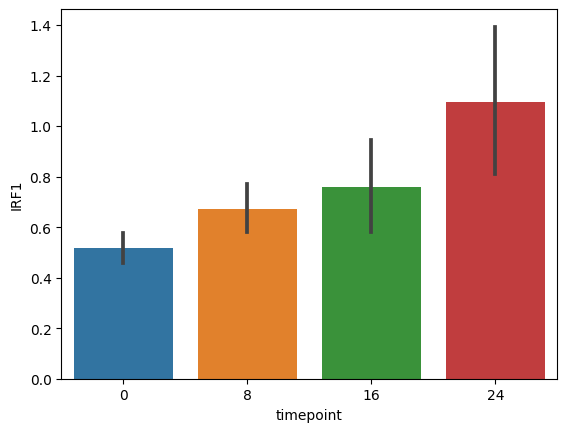

In [74]:
# barplot of timepoint vs IRF1
sns.barplot(x="timepoint", y = "IRF1", data=df)

<Axes: xlabel='timepoint', ylabel='IRF1'>

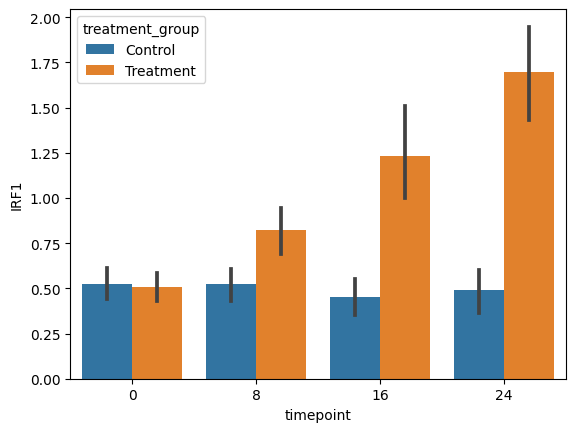

In [84]:
# barplot of timepoint vs IRF1 stratified by treatment_group
sns.barplot(x="timepoint", y = "IRF1", data=df, hue = "treatment_group")

## Customizing seaborn plots
Just about everything in a seaborn plot can be customized in some way. Let's look at some basic customizations you can make to the plot to enhance our visualizations.

Let's go back to our first barplot of `BAX` expression in each `treatment_group`. Let's use the `color` parameter to change the color of the bars to red.

<Axes: xlabel='treatment_group', ylabel='BAX'>

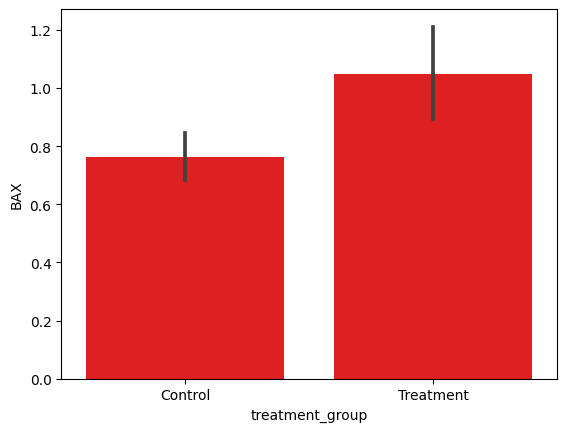

In [113]:
# barplot of treatment_group vs BAX with red bars
sns.barplot(x="treatment_group", y = "BAX", data=df, color = "red")

We can also change the color of the bar outlines (edges) with the `edgecolor` parameter.

<Axes: xlabel='treatment_group', ylabel='BAX'>

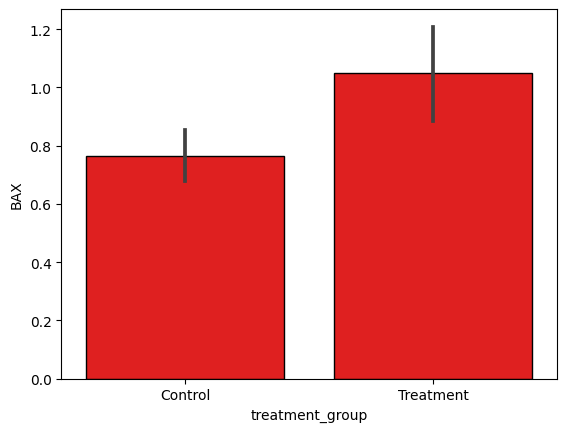

In [116]:
# barplot of treatment_group vs BAX with red bars and black edges
sns.barplot(x="treatment_group", y = "BAX", data=df, 
            color = "red", edgecolor = "black")

As we saw above, `color` lets us change the color of the whole plot. But if we want to specify the colors on a multi-colored plot, we need to set a palette with the `palette` parameter.

`palette` takes a list of colors equal to the number of colors in the plot. Let's try this with our plot of `timepoint` versus `IRF1` expression stratified by `treatment_group`.

<Axes: xlabel='timepoint', ylabel='IRF1'>

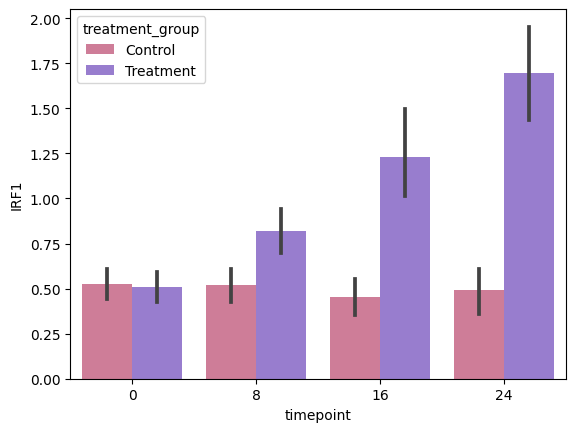

In [130]:
# use two color names to change the colors of the bars
sns.barplot(x="timepoint", y = "IRF1", data=df, 
            hue = "treatment_group", palette = ["PaleVioletRed", "mediumpurple"])

Seaborn also has built in palettes we can use if we don't want to pick every color by hand.

<Axes: xlabel='timepoint', ylabel='IRF1'>

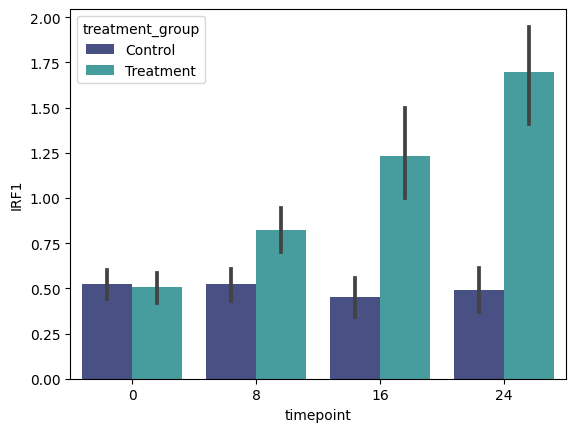

In [133]:
# use the mako palette to colors the bars
sns.barplot(x="timepoint", y = "IRF1", data=df, 
            hue = "treatment_group", palette = "mako")

So far we've been using names to specify colors, examples of names you can use can be found in a reference table here: https://htmlcolorcodes.com/color-names/

But what if the exact color we want isn't in the named table? We can use something called "hexcodes" instead. For example, the hexcode for "red" is "#FF0000". You can pick any color you want with this color picker: https://htmlcolorcodes.com/color-picker/

We can also see all color palettes available at this link: https://www.practicalpythonfordatascience.com/ap_seaborn_palette

**Exercise:** Try changing the colors on the plots below. Follow the instructions in the comments below for each plot. Use the links above to help you choose colors.


/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='BAX', ylabel='Count'>

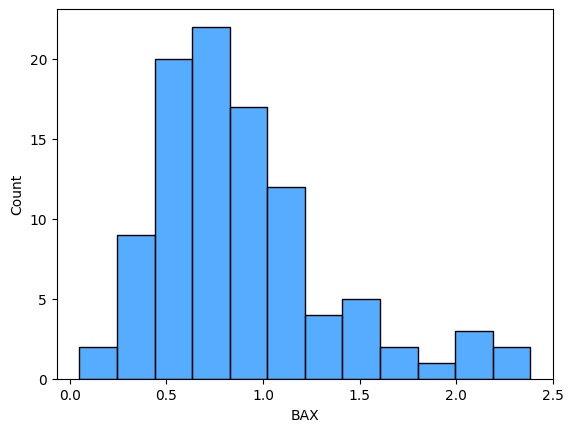

In [139]:
# change the bars to your favoite named color
sns.histplot(x = "BAX", data = df, color = "dodgerblue")

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='BAX', ylabel='Count'>

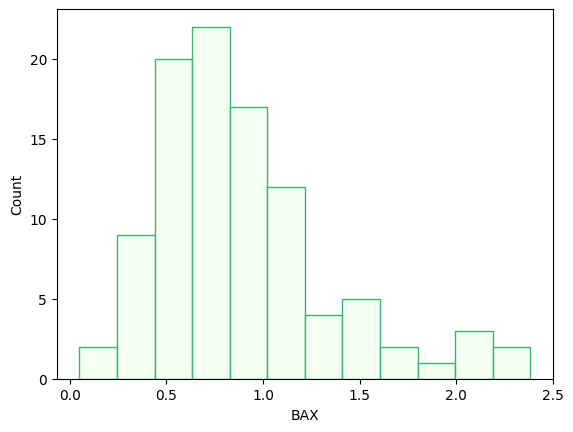

In [145]:
# change the bars and edgecolors to two different hexcodes
sns.histplot(x = "BAX", data = df, color = "#F0FFF0", edgecolor = "#3CB371")

<Axes: xlabel='treatment_group', ylabel='BAX'>

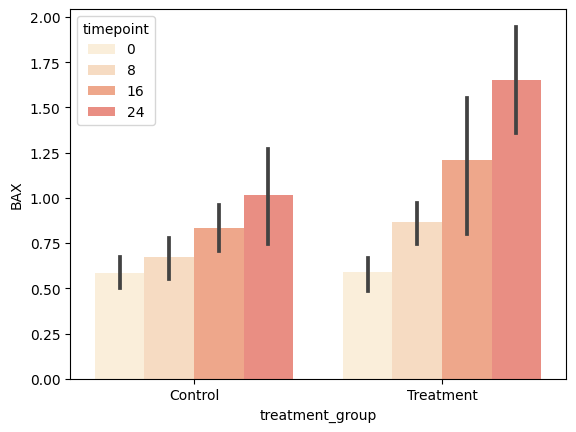

In [136]:
# pick 4 colors for the color palette
sns.barplot(x="treatment_group", y = "BAX", data=df, 
            hue = "timepoint", 
            palette = ["papayawhip", "peachpuff", "lightsalmon", "salmon"])

<Axes: xlabel='treatment_group', ylabel='BAX'>

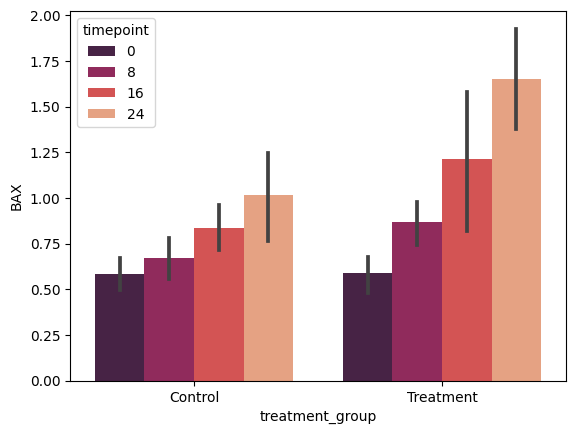

In [138]:
# color the bars using a named color palette
sns.barplot(x="treatment_group", y = "BAX", data=df, 
            hue = "timepoint", palette = "rocket")